# 05 - Model Evaluation

Model Evaluation is the process of measuring how well a Machine Learning model
performs on unseen data.

A model should not only perform well on training data.
It should also generalize well to new, unseen data.

In this notebook, we will learn:

- Why Model Evaluation is important
- Train-Test Evaluation
- Classification Metrics
- Confusion Matrix
- Accuracy
- Precision
- Recall
- F1-Score
- Classification Report
- Regression Metrics
- MAE
- MSE
- RMSE
- R² Score
- Cross-Validation
- Choosing the right evaluation metric

## 1. Import Required Libraries

We will import the libraries required for:

- Loading datasets
- Splitting data
- Building Machine Learning models
- Calculating evaluation metrics
- Visualizing the confusion matrix

In [3]:
# Dataset
from sklearn.datasets import load_breast_cancer, load_diabetes

# Data splitting
from sklearn.model_selection import train_test_split

# Classification model
from sklearn.linear_model import LogisticRegression

# Regression model
from sklearn.linear_model import LinearRegression

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Cross-validation
from sklearn.model_selection import cross_val_score

# Feature scaling
from sklearn.preprocessing import StandardScaler

# Numerical operations
import numpy as np

# Visualization
import matplotlib.pyplot as plt

## 2. What is Model Evaluation?

After training a Machine Learning model, we need to measure how well it
performs.

We evaluate the model using data that was not used during training.

The basic workflow is:

        Dataset
        ↓
        Split Data
        ↓
        Training Data → Train Model
        ↓
        Testing Data → Make Predictions
        ↓
        Compare Predictions with Actual Values
        ↓
        Calculate Evaluation Metrics

The main purpose of model evaluation is to understand how well the model
generalizes to unseen data.

## 3. Training Data and Testing Data

We usually divide our dataset into two parts:

### Training Data

Used to train the Machine Learning model.

### Testing Data

Used to evaluate the trained model on unseen data.

For example:

      80% → Training Data
      20% → Testing Data

The testing data should not be used while training the model.

### Train-Test Split

The `train_test_split()` function from Scikit-Learn is commonly used to divide
the dataset.

Example:

X_train → Training features
X_test  → Testing features

y_train → Training target
y_test  → Testing target

# 4. Classification Model Evaluation

Classification models predict discrete classes.

Examples:

- Spam / Not Spam
- Pass / Fail
- Disease / No Disease
- Cat / Dog

We will use the Breast Cancer dataset to demonstrate classification
evaluation.

## 5. Load Classification Dataset

In [4]:
# Load the Breast Cancer dataset
classification_data = load_breast_cancer()

# Store features and target
X_classification = classification_data.data
y_classification = classification_data.target

print("Feature shape:", X_classification.shape)
print("Target shape:", y_classification.shape)

Feature shape: (569, 30)
Target shape: (569,)


In [5]:
# Display feature names
print("Features:")
print(classification_data.feature_names)

print("\nTarget names:")
print(classification_data.target_names)

Features:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Target names:
['malignant' 'benign']


## 6. Split Classification Data

We will use:

- 80% of the data for training
- 20% of the data for testing

`stratify=y_classification` keeps the class distribution approximately the
same in both training and testing data.

In [6]:
# Split the classification dataset
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_classification,
    y_classification,
    test_size=0.2,
    random_state=42,
    stratify=y_classification
)

print("Training features:", X_train_cls.shape)
print("Testing features :", X_test_cls.shape)
print("Training target  :", y_train_cls.shape)
print("Testing target   :", y_test_cls.shape)

Training features: (455, 30)
Testing features : (114, 30)
Training target  : (455,)
Testing target   : (114,)


## 7. Feature Scaling

Logistic Regression can benefit from feature scaling because different
features may have very different numerical ranges.

We will:

1. Fit the scaler only on training data.
2. Transform training data.
3. Transform testing data using the same scaler.

We must not fit the scaler separately on the testing data.

In [7]:
# Create the scaler
scaler_cls = StandardScaler()

# Fit and transform training data
X_train_cls_scaled = scaler_cls.fit_transform(X_train_cls)

# Transform testing data
X_test_cls_scaled = scaler_cls.transform(X_test_cls)

print("Training data scaled.")
print("Testing data scaled.")

Training data scaled.
Testing data scaled.


## 8. Train the Classification Model

We will use Logistic Regression for classification.

In [8]:
# Create Logistic Regression model
classification_model = LogisticRegression(max_iter=1000)

# Train the model
classification_model.fit(
    X_train_cls_scaled,
    y_train_cls
)

print("Classification model trained successfully.")

Classification model trained successfully.


## 9. Make Predictions

After training the model, we use the testing data to make predictions.

The model has never seen `X_test_cls_scaled` during training.

In [9]:
# Make predictions on testing data
y_pred_cls = classification_model.predict(X_test_cls_scaled)

print("Predictions:")
print(y_pred_cls[:20])

Predictions:
[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1]


## 10. Confusion Matrix

```text
A confusion matrix shows how the predicted classes compare with the actual
classes.

For binary classification:

                Actual
              Positive Negative

Predicted
Positive        TP       FP

Negative        FN       TN

TP = True Positive
TN = True Negative
FP = False Positive
FN = False Negative

In [10]:
# Calculate confusion matrix
cm = confusion_matrix(
    y_test_cls,
    y_pred_cls
)

print(cm)

[[41  1]
 [ 1 71]]


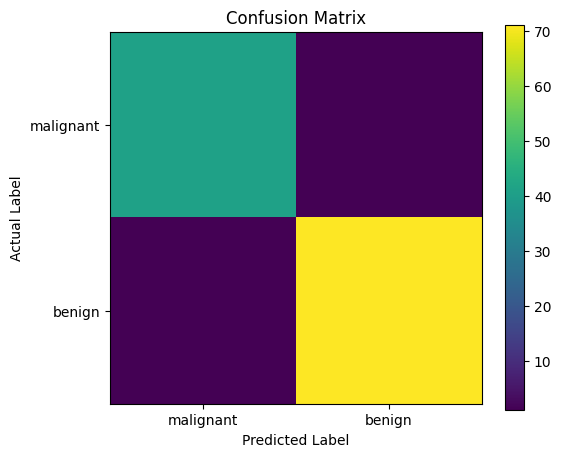

In [11]:
# Visualize confusion matrix
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    classification_data.target_names
)

plt.yticks(
    [0, 1],
    classification_data.target_names
)

plt.colorbar()

plt.show()

## 11. Accuracy

Accuracy tells us how many predictions were correct out of all predictions.

Formula:

Accuracy = Correct Predictions / Total Predictions

For binary classification:

Accuracy = (TP + TN) / (TP + TN + FP + FN)

A higher accuracy is generally better.

However, accuracy can be misleading when the classes are highly imbalanced.

In [12]:
# Calculate accuracy
accuracy = accuracy_score(
    y_test_cls,
    y_pred_cls
)

print("Accuracy:", accuracy)

Accuracy: 0.9824561403508771


## 12. Precision

Precision answers:

"Out of all the samples predicted as positive, how many were actually
positive?"

Formula:

Precision = TP / (TP + FP)

Precision is especially important when False Positives are costly.

Example:

In spam detection, an important email incorrectly classified as spam is
a False Positive.

In [13]:
# Calculate precision
precision = precision_score(
    y_test_cls,
    y_pred_cls
)

print("Precision:", precision)

Precision: 0.9861111111111112


## 13. Recall

Recall answers:

"Out of all the actual positive samples, how many did the model correctly
identify?"

Formula:

Recall = TP / (TP + FN)

Recall is especially important when False Negatives are costly.

Example:

In disease detection, failing to identify a person who actually has the
disease is a False Negative.

In [14]:
# Calculate recall
recall = recall_score(
    y_test_cls,
    y_pred_cls
)

print("Recall:", recall)

Recall: 0.9861111111111112


## 14. F1-Score

F1-Score combines Precision and Recall into a single metric.

Formula:

F1 = 2 × (Precision × Recall) / (Precision + Recall)

F1-Score is useful when we want a balance between Precision and Recall.

A higher F1-Score is generally better.

In [15]:
# Calculate F1-Score
f1 = f1_score(
    y_test_cls,
    y_pred_cls
)

print("F1-Score:", f1)

F1-Score: 0.9861111111111112


## 15. Classification Report

The classification report provides:

- Precision
- Recall
- F1-Score
- Support

for each class.

In [16]:
# Display classification report
print(
    classification_report(
        y_test_cls,
        y_pred_cls,
        target_names=classification_data.target_names
    )
)

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## 16. Classification Metrics Summary

In [17]:
# Display all major classification metrics
print("Classification Model Evaluation")
print("-" * 35)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Classification Model Evaluation
-----------------------------------
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1-Score : 0.9861


# 17. Regression Model Evaluation

Regression models predict continuous numerical values.

Examples:

- House price prediction
- Salary prediction
- Sales prediction
- Temperature prediction

We will use the Diabetes dataset to demonstrate regression evaluation.

## 18. Load Regression Dataset

In [18]:
# Load the Diabetes dataset
regression_data = load_diabetes()

# Store features and target
X_regression = regression_data.data
y_regression = regression_data.target

print("Feature shape:", X_regression.shape)
print("Target shape:", y_regression.shape)

Feature shape: (442, 10)
Target shape: (442,)


## 19. Split Regression Data

We will again use:

        80% → Training Data
        20% → Testing Data

In [19]:
# Split the regression dataset
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_regression,
    y_regression,
    test_size=0.2,
    random_state=42
)

print("Training features:", X_train_reg.shape)
print("Testing features :", X_test_reg.shape)
print("Training target  :", y_train_reg.shape)
print("Testing target   :", y_test_reg.shape)

Training features: (353, 10)
Testing features : (89, 10)
Training target  : (353,)
Testing target   : (89,)


## 20. Train the Regression Model

We will use Linear Regression for this example.

In [20]:
# Create Linear Regression model
regression_model = LinearRegression()

# Train the model
regression_model.fit(
    X_train_reg,
    y_train_reg
)

print("Regression model trained successfully.")

Regression model trained successfully.


## 21. Make Predictions

We now use the testing data to generate predictions.

In [21]:
# Make predictions on testing data
y_pred_reg = regression_model.predict(X_test_reg)

print("Predictions:")
print(y_pred_reg[:10])

Predictions:
[139.5475584  179.51720835 134.03875572 291.41702925 123.78965872
  92.1723465  258.23238899 181.33732057  90.22411311 108.63375858]


## 22. Mean Absolute Error (MAE)

```text
MAE measures the average absolute difference between actual and predicted
values.

Formula:

MAE = (1/n) Σ |yᵢ - ŷᵢ|

where:

yᵢ = Actual value
ŷᵢ = Predicted value

Lower MAE is better.

In [22]:
# Calculate MAE
mae = mean_absolute_error(
    y_test_reg,
    y_pred_reg
)

print("MAE:", mae)

MAE: 42.79409467959994


## 23. Mean Squared Error (MSE)

```text
MSE calculates the average squared difference between actual and predicted
values.

Formula:

MSE = (1/n) Σ (yᵢ - ŷᵢ)²

Because the errors are squared, larger errors receive a greater penalty.

Lower MSE is better.

In [23]:
# Calculate MSE
mse = mean_squared_error(
    y_test_reg,
    y_pred_reg
)

print("MSE:", mse)

MSE: 2900.1936284934795


## 24. Root Mean Squared Error (RMSE)

RMSE is the square root of MSE.

Formula:

RMSE = √MSE

RMSE is expressed in the same unit as the target variable.

Lower RMSE is better.

In [24]:
# Calculate RMSE
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 53.85344583676591


## 25. R² Score

```text
R² measures how much of the variation in the target variable is explained
by the model.

Formula:

R² = 1 - [Σ(yᵢ - ŷᵢ)² / Σ(yᵢ - ȳ)²]

Interpretation:

R² = 1 → Perfect prediction

R² = 0 → Model performs approximately like predicting the mean

R² < 0 → Model performs worse than the mean baseline

Higher R² is generally better.

In [25]:
# Calculate R² Score
r2 = r2_score(
    y_test_reg,
    y_pred_reg
)

print("R² Score:", r2)

R² Score: 0.4526027629719198


## 26. Regression Metrics Summary

In [26]:
# Display all major regression metrics
print("Regression Model Evaluation")
print("-" * 30)

print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

Regression Model Evaluation
------------------------------
MAE : 42.7941
MSE : 2900.1936
RMSE: 53.8534
R²  : 0.4526


# 27. Cross-Validation

A single train-test split may not always provide a reliable estimate of
model performance.

Cross-validation solves this problem by dividing the dataset into multiple
folds.

For example, with 5-Fold Cross-Validation:

        Fold 1 → Testing
        Fold 2 → Training
        Fold 3 → Training
        Fold 4 → Training
        Fold 5 → Training

Then the process is repeated so that every fold becomes the testing fold.

Finally, we calculate the average score.

In [27]:
# Perform 5-Fold Cross-Validation
cv_scores = cross_val_score(
    regression_model,
    X_regression,
    y_regression,
    cv=5,
    scoring="r2"
)

print("Cross-Validation Scores:")
print(cv_scores)

Cross-Validation Scores:
[0.42955615 0.52259939 0.48268054 0.42649776 0.55024834]


In [28]:
# Calculate average cross-validation score
cv_mean = cv_scores.mean()

print("Mean Cross-Validation R²:", cv_mean)

Mean Cross-Validation R²: 0.4823164359086422


## 29. Why Use Cross-Validation?

Cross-validation helps us:

- Use the dataset more effectively
- Obtain a more reliable performance estimate
- Detect unstable models
- Compare different models
- Reduce dependence on one particular train-test split

A model that performs consistently across different folds is generally
more reliable.

# 30. Choosing the Right Evaluation Metric

There is no single best metric for every Machine Learning problem.

## Classification

### Accuracy

Useful when classes are reasonably balanced.

### Precision

Useful when False Positives are costly.

### Recall

Useful when False Negatives are costly.

### F1-Score

Useful when we need a balance between Precision and Recall.

## Regression

### MAE

Easy to interpret and treats errors linearly.

### MSE

Penalizes large errors more strongly.

### RMSE

Penalizes large errors and is expressed in the same unit as the target.

### R²

Measures how much variation in the target is explained by the model.

## 31. Metric Comparison

| Metric | Problem | Better Value |
|---|---|---|
| Accuracy | Classification | Higher |
| Precision | Classification | Higher |
| Recall | Classification | Higher |
| F1-Score | Classification | Higher |
| MAE | Regression | Lower |
| MSE | Regression | Lower |
| RMSE | Regression | Lower |
| R² | Regression | Higher |

Remember:

Higher is better:
- Accuracy
- Precision
- Recall
- F1-Score
- R²

Lower is better:
- MAE
- MSE
- RMSE

# 32. Model Evaluation Workflow

A typical evaluation workflow is:

1. Load the dataset
2. Separate features and target
3. Split the data
4. Preprocess the data
5. Train the model
6. Make predictions on unseen data
7. Calculate appropriate evaluation metrics
8. Analyze the results
9. Use Cross-Validation when appropriate

The important point is:

**Choose the evaluation metric according to the Machine Learning problem
and the cost of different types of errors.**

# 33. Summary

In this notebook, we learned how to evaluate Machine Learning models.

### Classification

We learned:

- Confusion Matrix
- Accuracy
- Precision
- Recall
- F1-Score
- Classification Report

### Regression

We learned:

- MAE
- MSE
- RMSE
- R² Score

### Additional Technique

- K-Fold Cross-Validation

The goal of Model Evaluation is not simply to obtain a high score.

The goal is to determine whether the model performs well on unseen data
and whether its errors are acceptable for the actual problem.